In [1]:
import torch
from model import mnistINR
import sys
import os
from pathlib import Path

# Add the parent directory to the path so Python can find 'src'
sys.path.append(os.path.abspath(".."))
from src.tokenizer import INRTokenizer

tokenizer = INRTokenizer(sort=False, token="neuron") 

all_neurons_flat = []

for i in range(10):
    model_path = Path(f"checkpoints-rec/all_inrs_eight_neurons/digit_{i}")
    files = [f.name for f in model_path.iterdir()]
    for model_dir in files:
        model = mnistINR()
        model.load_state_dict(torch.load(model_path / model_dir, map_location='cpu'))
        
        sd = model.state_dict()
        tokenized_model = tokenizer.tokenize(sd)
        
        for idx, layer in enumerate(tokenized_model):
            for neuron_tensor in layer:
                all_neurons_flat.append((neuron_tensor.numpy(),i,idx))

In [2]:
import numpy as np
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
shapes = [item[0].shape for item in all_neurons_flat]
unique_shapes = set(shapes)

print(f"Total items: {len(shapes)}")
print(f"Unique shapes found in your data: {unique_shapes}")

# Print a breakdown of how many items have each shape
for shape in unique_shapes:
    count = shapes.count(shape)
    print(f"Shape {shape}: appears {count} times")

Total items: 1020000
Unique shapes found in your data: {(9,)}
Shape (9,): appears 1020000 times


In [3]:
import numpy as np
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

neuron_matrix = np.stack([item[0] for item in all_neurons_flat]) 
print(f"Shape of neuron matrix: {neuron_matrix.shape}") 
# neuron_matrix should be shape (N_total_neurons, Token_Dim)
# Ensure it is float32 for t-SNE
neuron_matrix = neuron_matrix.astype(np.float32)

# It is highly recommended to normalize data before t-SNE
from sklearn.preprocessing import StandardScaler
neuron_matrix_scaled = StandardScaler().fit_transform(neuron_matrix)

digits = np.array([item[1] for item in all_neurons_flat])
idxs = np.array([item[2] for item in all_neurons_flat])


np.random.seed(42)

random_indices = np.random.choice(1020000, size=10000, replace=False)

random_indices.sort()

neuron_matrix_scaled_sample = neuron_matrix_scaled[random_indices]
digits_sample = digits[random_indices]
idxs_sample = idxs[random_indices]

Shape of neuron matrix: (1020000, 9)


In [4]:
# Initialize t-SNE
# perplexity: roughly the number of neighbors to consider (try 5-30)
tsne = TSNE(
    n_components=2,
    perplexity=30,      # Reduced from 30 for your smaller sample size
    early_exaggeration=10.0,
    learning_rate='auto',
    init='pca', 
    random_state=42,
    n_iter=1000
)

# Fit and transform
embeddings = tsne.fit_transform(neuron_matrix_scaled_sample)

/home/theseeker/miniconda3/envs/neural-graphs/lib/python3.9/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


/tmp/ipykernel_30324/196071082.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('Set1', num_categories)


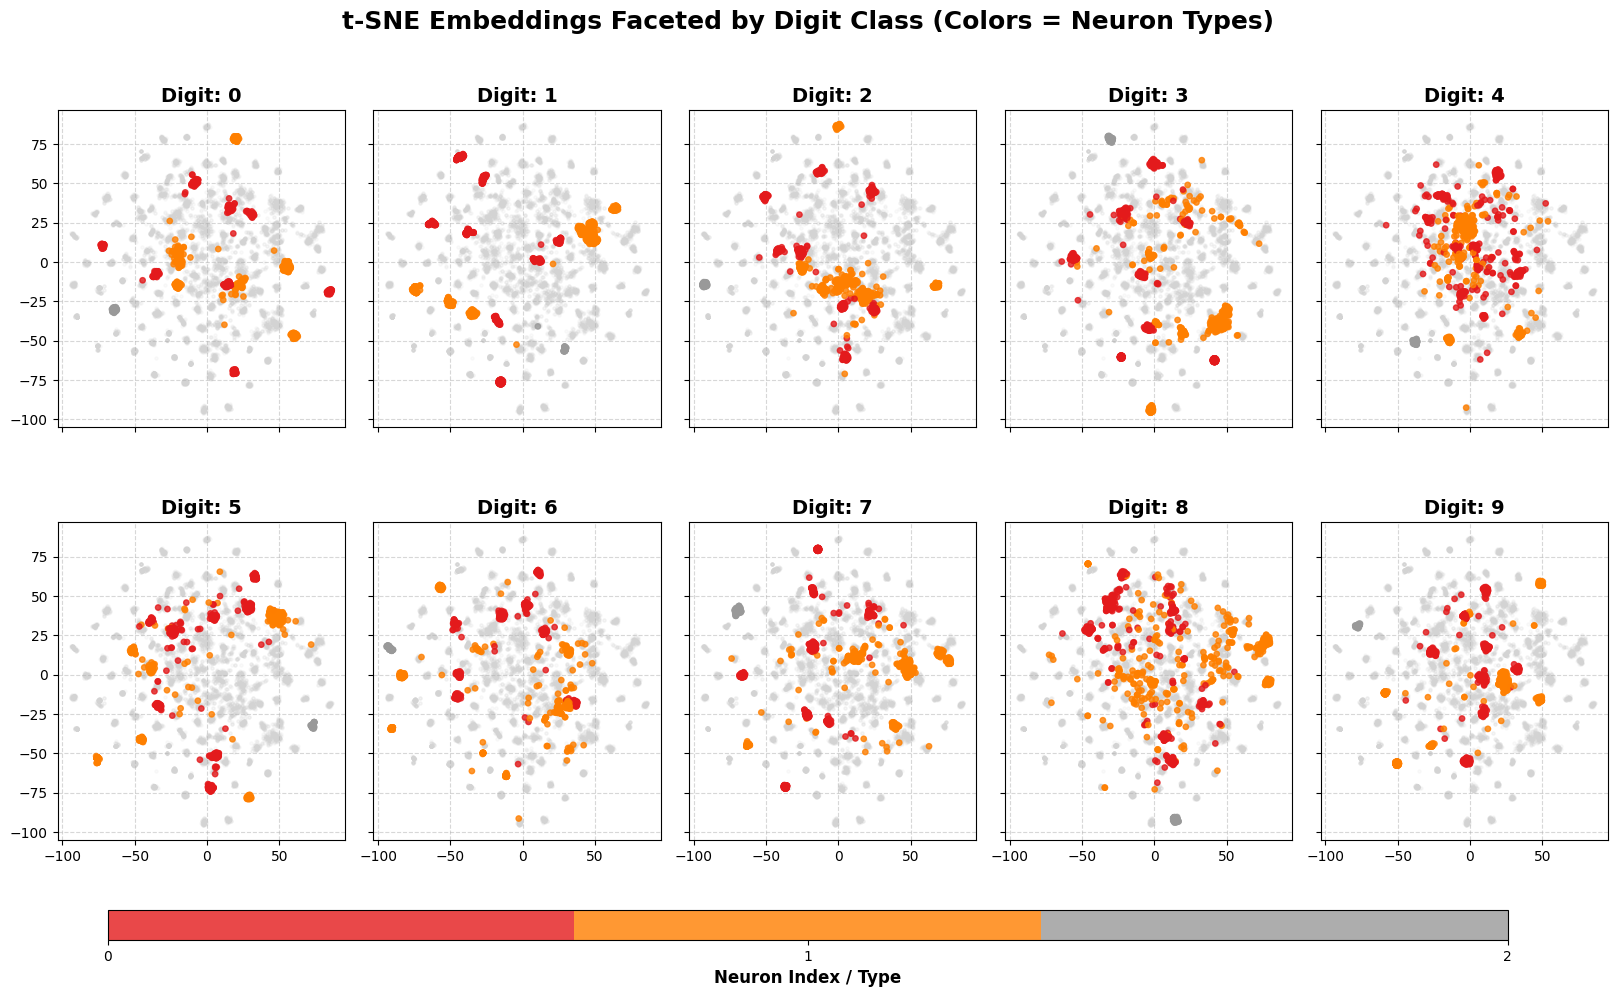

In [6]:
import matplotlib.pyplot as plt
import numpy as np

# Create a 2x5 grid of subplots (one for each MNIST digit)
fig, axes = plt.subplots(2, 5, figsize=(20, 10), sharex=True, sharey=True)
axes = axes.flatten()

unique_idxs = np.unique(idxs_sample)
num_categories = len(unique_idxs)

# Use a vibrant qualitative colormap for the neuron indices (e.g., 'Set1' or 'Dark2')
cmap = plt.cm.get_cmap('Set1', num_categories)

for digit in range(10):
    ax = axes[digit]
    
    # 1. Plot a faint background of ALL points so you can see the global t-SNE shape
    ax.scatter(embeddings[:, 0], embeddings[:, 1], c='lightgray', alpha=0.1, s=5, zorder=1)
    
    # 2. Filter data for just THIS specific digit
    digit_mask = (digits_sample == digit)
    
    if np.any(digit_mask):
        x_coords = embeddings[digit_mask, 0]
        y_coords = embeddings[digit_mask, 1]
        neuron_types = idxs_sample[digit_mask]
        
        # 3. Plot points for this digit, colored cleanly by Neuron Type (All circles!)
        scatter = ax.scatter(
            x_coords,
            y_coords,
            c=neuron_types,
            cmap=cmap,
            alpha=0.8,
            s=15,
            vmin=unique_idxs.min(),
            vmax=unique_idxs.max(),
            zorder=2
        )
        
    ax.set_title(f"Digit: {digit}", fontsize=14, fontweight='bold')
    ax.grid(True, linestyle='--', alpha=0.5)

# Add a unified colorbar at the bottom to show what the Neuron Types mean
cbar_ax = fig.add_axes([0.15, 0.05, 0.7, 0.03]) # [left, bottom, width, height]
cbar = fig.colorbar(scatter, cax=cbar_ax, orientation='horizontal', ticks=unique_idxs)
cbar.set_label("Neuron Index / Type", fontsize=12, fontweight='bold')

plt.suptitle("t-SNE Embeddings Faceted by Digit Class (Colors = Neuron Types)", fontsize=18, y=0.98, fontweight='bold')
plt.subplots_adjust(bottom=0.15, top=0.88, hspace=0.3, wspace=0.1)
plt.show()